# Shendure pairwise CRE power analysis — MWU

Measures MWU test power for **pairwise CRE comparisons** as a function of
(baseline activity, fold change). Each simulation places "anchor" CREs at
log-spaced baselines and "variant" CREs at fine FC offsets around each anchor.
The hypothesis set tests each variant against its anchor.

Motivated by variant effect detection: >90% of real MPRA variant effects have
log2(FC) < 0.2, so we focus on the 2–30% fold-change range.

Cell types with fewer CREs are split into multiple cohorts that tile the
anchor space; results are aggregated across cohorts.

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import uuid
import pickle

%load_ext autoreload
%autoreload 2

In [2]:
data_root = Path("/gpfs/gibbs/pi/reilly/tabula_data")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
sim_date = "2026-03-24"

In [3]:
local = False
if local:
    from dask.distributed import LocalCluster
    cluster = LocalCluster(memory_limit='48G')
    client = Client(cluster)
else:
    cluster = SLURMCluster(
        cores=3,
        memory="16G",
        processes=3,
        worker_extra_args=["--nthreads", "2"],
        job_extra_directives=[
            "-p ycga",
            "--job-name=simclust_worker",
            "--time=6:00:00",
            "--output=worker_%j.out"
        ]
    )
    cluster.scale(jobs=10)
    client = Client(
        cluster,
        timeout=f"{5*60}s",
        heartbeat_interval="20s"
    )
print(client.dashboard_link, flush=True)

http://10.178.138.12:8787/status


In [4]:
# Load per-cell-type n_cres from the ortho parameters.
with open(data_root / "shendure" / "shendure_ortho_20260306" / "by_cell_type_parameters.pkl", "rb") as f:
    _params = pickle.load(f)

n_cres_per_ct = {ct: len(_params.nb[ct]) for ct in _params.nb}
cell_types = sorted(n_cres_per_ct.keys())
del _params

print("Cell types:")
for ct in cell_types:
    cells = scm.SHENDURE_BOUNDS.cells_per_cell_type.get(ct, "?")
    print(f"  {ct}: n_cres={n_cres_per_ct[ct]}, cells={cells}")

Cell types:
  Cardiomyocytes: n_cres=79, cells=680
  EpiblastPrimitiveStreak: n_cres=185, cells=3445
  ExEndodermParietal: n_cres=178, cells=4644
  ExEndodermVisceral: n_cres=148, cells=3238
  Haematoendothelial: n_cres=91, cells=1079
  Mesoderm: n_cres=177, cells=7427
  NeuroectodermBrain: n_cres=173, cells=7750
  NeuroectodermRostral: n_cres=85, cells=1757
  SurfaceEctoderm: n_cres=139, cells=5168
  reference: n_cres=207, cells=8201


## Grid parameters & cohort assignments

In [5]:
minP = scm.SHENDURE_BOUNDS.reference_activity

# 24 anchor baselines, log-spaced from minP to 99th percentile of observed mu
n_total_anchors = 24
anchor_baselines = np.geomspace(minP, 40.0, n_total_anchors)

# FC offsets (positive only — MWU is symmetric)
fc_log2_offsets = np.array([0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30])

cres_per_anchor = 1 + len(fc_log2_offsets)  # anchor + variants
n_library_reps = 20
n_sims = 5

print(f"minP = {minP:.6f}")
print(f"Anchor baselines ({n_total_anchors}): {[f'{x:.4f}' for x in anchor_baselines]}")
print(f"FC offsets (log2): {list(fc_log2_offsets)}")
print(f"CREs per anchor cluster: {cres_per_anchor}")
print(f"Library reps: {n_library_reps}, sims per rep: {n_sims}")

minP = 0.019311
Anchor baselines (24): ['0.0193', '0.0269', '0.0375', '0.0523', '0.0729', '0.1016', '0.1416', '0.1973', '0.2750', '0.3832', '0.5341', '0.7445', '1.0376', '1.4461', '2.0155', '2.8092', '3.9153', '5.4569', '7.6056', '10.6003', '14.7742', '20.5916', '28.6995', '40.0000']
FC offsets (log2): [np.float64(0.02), np.float64(0.03), np.float64(0.05), np.float64(0.07), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.3)]
CREs per anchor cluster: 9
Library reps: 20, sims per rep: 5


In [6]:
# Compute cohort assignments per cell type.
# Round-robin: cohort k gets anchors [k, k+C, k+2C, ...]
cohort_assignments = {}  # {cell_type: [[anchor_indices_cohort_0], [anchor_indices_cohort_1], ...]}

for ct in cell_types:
    n_cres = n_cres_per_ct[ct]
    max_anchors = (n_cres - 1) // cres_per_anchor  # -1 for reference CRE
    n_cohorts = int(np.ceil(n_total_anchors / max_anchors))
    
    cohorts = [[] for _ in range(n_cohorts)]
    for i in range(n_total_anchors):
        cohorts[i % n_cohorts].append(i)
    
    cohort_assignments[ct] = cohorts
    print(f"{ct}: n_cres={n_cres}, max_anchors/cohort={max_anchors}, "
          f"n_cohorts={n_cohorts}, anchors/cohort={[len(c) for c in cohorts]}")

Cardiomyocytes: n_cres=79, max_anchors/cohort=8, n_cohorts=3, anchors/cohort=[8, 8, 8]
EpiblastPrimitiveStreak: n_cres=185, max_anchors/cohort=20, n_cohorts=2, anchors/cohort=[12, 12]
ExEndodermParietal: n_cres=178, max_anchors/cohort=19, n_cohorts=2, anchors/cohort=[12, 12]
ExEndodermVisceral: n_cres=148, max_anchors/cohort=16, n_cohorts=2, anchors/cohort=[12, 12]
Haematoendothelial: n_cres=91, max_anchors/cohort=10, n_cohorts=3, anchors/cohort=[8, 8, 8]
Mesoderm: n_cres=177, max_anchors/cohort=19, n_cohorts=2, anchors/cohort=[12, 12]
NeuroectodermBrain: n_cres=173, max_anchors/cohort=19, n_cohorts=2, anchors/cohort=[12, 12]
NeuroectodermRostral: n_cres=85, max_anchors/cohort=9, n_cohorts=3, anchors/cohort=[8, 8, 8]
SurfaceEctoderm: n_cres=139, max_anchors/cohort=15, n_cohorts=2, anchors/cohort=[12, 12]
reference: n_cres=207, max_anchors/cohort=22, n_cohorts=2, anchors/cohort=[12, 12]


## Helper functions

In [7]:
def build_ground_truth(cell_type, anchor_indices, n_cres, anchor_baselines, fc_log2_offsets, minP):
    """Build ground truth DataFrame for one cohort.
    
    Places anchor + variant CREs at specified activities,
    fills remaining slots with filler CREs at minP,
    and adds a reference CRE at minP.
    """
    names = []
    mus = []
    
    for a_idx in anchor_indices:
        baseline = anchor_baselines[a_idx]
        # Anchor CRE
        names.append(f"anchor_{a_idx}")
        mus.append(baseline)
        # Variant CREs
        for fc_l2 in fc_log2_offsets:
            names.append(f"anchor_{a_idx}_fc_{fc_l2:.2f}")
            mus.append(baseline * 2**fc_l2)
    
    # Filler CREs at minP to reach exact n_cres
    n_used = len(names) + 1  # +1 for reference
    n_filler = n_cres - n_used
    for j in range(n_filler):
        names.append(f"filler_{j}")
        mus.append(minP)
    
    # Reference CRE
    names.append("reference")
    mus.append(minP)
    
    assert len(names) == n_cres, f"Expected {n_cres} CREs, got {len(names)}"
    
    return pd.DataFrame({"cre_id": names, "mu": mus, "cell_type": cell_type})


def build_pairwise_hypotheses(anchor_indices, cell_type, fc_log2_offsets, n_filler_null=5):
    """Build HypothesisSet for pairwise power testing.
    
    Each variant CRE is compared to its anchor CRE (same cell type).
    Also includes filler-vs-filler null pairs for calibration checks.
    """
    rows = []
    
    # Power rows: variant vs anchor
    for a_idx in anchor_indices:
        anchor_name = f"anchor_{a_idx}"
        for fc_l2 in fc_log2_offsets:
            variant_name = f"anchor_{a_idx}_fc_{fc_l2:.2f}"
            rows.append({
                "comparison_CRE": variant_name,
                "comparison_cell_type": cell_type,
                "reference_CRE": anchor_name,
                "reference_cell_type": cell_type,
                "meta": f"power_fc_{fc_l2:.2f}",
            })
    
    # Null calibration rows: filler vs filler
    for j in range(0, n_filler_null * 2, 2):
        rows.append({
            "comparison_CRE": f"filler_{j}",
            "comparison_cell_type": cell_type,
            "reference_CRE": f"filler_{j+1}",
            "reference_cell_type": cell_type,
            "meta": "null_check",
        })
    
    return scm.HypothesisSet.from_dataframe(pd.DataFrame(rows))

## Run simulations

In [8]:
sim_registry = []  # list of (cell_type, cohort_idx, sim_location, sim_name)

for ct in cell_types:
    n_cres = n_cres_per_ct[ct]
    cohorts = cohort_assignments[ct]
    
    # Per-cell-type bounds
    bound_ct = scm.SHENDURE_BOUNDS.copy()
    bound_ct.cells_per_cell_type = scm.SHENDURE_BOUNDS.cells_per_cell_type.loc[[ct]]
    
    for cohort_idx, anchor_indices in enumerate(cohorts):
        print(f"\n=== {ct} cohort {cohort_idx}/{len(cohorts)-1} "
              f"({len(anchor_indices)} anchors) ===", flush=True)
        
        # Build hypothesis set (same for all library reps in this cohort)
        hs = build_pairwise_hypotheses(anchor_indices, ct, fc_log2_offsets)
        
        for lib_rep in range(n_library_reps):
            # Build ground truth (same anchors, fresh random seed for library)
            gt_df = build_ground_truth(
                ct, anchor_indices, n_cres,
                anchor_baselines, fc_log2_offsets, minP
            )
            
            libraries = [
                scm.simulate_library(
                    CREs=pd.Series(gt_df["cre_id"].values),
                    library_model=scm.SHENDURE_BOUNDS.library_model,
                )
                for _ in range(n_sims)
            ]
            
            sim_name = f"sim_{uuid.uuid4().hex[:8]}"
            sim_loc = data_root / f"{sim_date}_shendure_pw" / ct / f"cohort_{cohort_idx}"
            
            sim = scm.de_novo_simulation(
                location=sim_loc,
                name=sim_name,
                client=client,
                libraries=libraries,
                library_mapping="corresponding",
                flatten_overtransfection=False,
                n_sims=n_sims,
                experiment_bounds=bound_ct,
                ground_truth=gt_df,
            )
            sim.gamut()
            sim.add_hypothesis_set("hs_pairwise", hs)
            sim.mwu("hs_pairwise")
            sim.save()
            
            sim_registry.append((ct, cohort_idx, str(sim_loc), sim_name))
        
        print(f"  {n_library_reps} library reps done", flush=True)

print(f"\nTotal simulations: {len(sim_registry)}", flush=True)


=== Cardiomyocytes cohort 0/2 (8 anchors) ===


scMPRAforge: INFO: No 'state.parquet' found for 'sim_1665d0db'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_c9a44d3b'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_b05916f5'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_971fd2b4'. Initalizing new object.


...

scMPRAforge: INFO: No 'state.parquet' found for 'sim_bf36b608'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_a845cb3b'. Initalizing new object.


scMPRAforge: INFO: No 'state.parquet' found for 'sim_cffcf53e'. Initalizing new object.


  20 library reps done



Total simulations: 460


In [9]:
# Save registry for resumability
import json
registry_path = output_dir / "pairwise_power_sim_registry.json"
with open(registry_path, "w") as f:
    json.dump(sim_registry, f, indent=2)
print(f"Registry saved: {registry_path} ({len(sim_registry)} sims)")

Registry saved: output/pairwise_power_sim_registry.json (460 sims)


## Aggregate results

In [10]:
# Collect power results across all sims.
power_rows = []
null_rows = []

for ct, cohort_idx, sim_loc_str, sim_name in sim_registry:
    sim = scm.de_novo_simulation(
        location=Path(sim_loc_str), name=sim_name, client=client
    )
    gt = sim.ground_truth
    
    for i in range(sim.get_state_field("n_sims")):
        m = sim._merge_in_ground_truth(
            hypothesis_set_name="hs_pairwise", test_type="mwu", index=i
        )
        
        for _, row in m.iterrows():
            cre_name = row["comparison_CRE"]
            
            if "_fc_" in cre_name:
                # Power row: parse anchor index and FC
                parts = cre_name.split("_fc_")
                anchor_name = parts[0]  # e.g. "anchor_3"
                log2_fc = float(parts[1])
                anchor_mu = gt[gt["cre_id"] == anchor_name]["mu"].iloc[0]
                
                power_rows.append({
                    "cell_type": ct,
                    "baseline_mu": anchor_mu,
                    "log2_fc": log2_fc,
                    "p_value": row["p_value"],
                    "reject_null": row["p_value"] < 0.05,
                })
            elif cre_name.startswith("filler_"):
                # Null calibration row
                null_rows.append({
                    "cell_type": ct,
                    "p_value": row["p_value"],
                })

power_df = pd.DataFrame(power_rows)
null_df = pd.DataFrame(null_rows)

print(f"Power tests: {len(power_df)}")
print(f"Null tests: {len(null_df)}")

# Inline calibration check
for ct in cell_types:
    ct_null = null_df[null_df["cell_type"] == ct]
    if len(ct_null) > 0:
        fpr = ct_null["p_value"].lt(0.05).mean()
        print(f"  {ct}: null FPR@0.05 = {fpr:.4f} (n={len(ct_null)})")

scMPRAforge: INFO: 'state.parquet' found for 'sim_1665d0db', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_c9a44d3b', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_b05916f5', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_971fd2b4', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_0f3491b6', loading.


...

scMPRAforge: INFO: 'state.parquet' found for 'sim_e83023f9', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_bf36b608', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_a845cb3b', loading.


scMPRAforge: INFO: 'state.parquet' found for 'sim_cffcf53e', loading.


Power tests: 192000
Null tests: 10900
  Cardiomyocytes: null FPR@0.05 = 0.0478 (n=900)
  EpiblastPrimitiveStreak: null FPR@0.05 = 0.0500 (n=1000)
  ExEndodermParietal: null FPR@0.05 = 0.0530 (n=1000)
  ExEndodermVisceral: null FPR@0.05 = 0.0470 (n=1000)
  Haematoendothelial: null FPR@0.05 = 0.0387 (n=1500)
  Mesoderm: null FPR@0.05 = 0.0470 (n=1000)
  NeuroectodermBrain: null FPR@0.05 = 0.0610 (n=1000)
  NeuroectodermRostral: null FPR@0.05 = 0.0433 (n=1500)
  SurfaceEctoderm: null FPR@0.05 = 0.0550 (n=1000)
  reference: null FPR@0.05 = 0.0390 (n=1000)


In [11]:
# Compute power per (cell_type, baseline_mu, log2_fc) grid cell.
power_grid = (
    power_df
    .groupby(["cell_type", "baseline_mu", "log2_fc"])
    .agg(power=("reject_null", "mean"), n_tests=("reject_null", "count"))
    .reset_index()
)

print(f"Grid cells: {len(power_grid)}")
print(power_grid.head(20))

Grid cells: 1920
         cell_type  baseline_mu  log2_fc  power  n_tests
0   Cardiomyocytes     0.019311     0.02   0.02      100
1   Cardiomyocytes     0.019311     0.03   0.03      100
2   Cardiomyocytes     0.019311     0.05   0.07      100
3   Cardiomyocytes     0.019311     0.07   0.06      100
4   Cardiomyocytes     0.019311     0.10   0.08      100
5   Cardiomyocytes     0.019311     0.15   0.02      100
6   Cardiomyocytes     0.019311     0.20   0.00      100
7   Cardiomyocytes     0.019311     0.30   0.08      100
8   Cardiomyocytes     0.026915     0.02   0.08      100
9   Cardiomyocytes     0.026915     0.03   0.05      100
10  Cardiomyocytes     0.026915     0.05   0.07      100
11  Cardiomyocytes     0.026915     0.07   0.05      100
12  Cardiomyocytes     0.026915     0.10   0.07      100
13  Cardiomyocytes     0.026915     0.15   0.03      100
14  Cardiomyocytes     0.026915     0.20   0.08      100
15  Cardiomyocytes     0.026915     0.30   0.08      100
16  Cardiomyoc

## Heatmap plots

Saved: output/pairwise_power_mwu_all_cell_types.svg


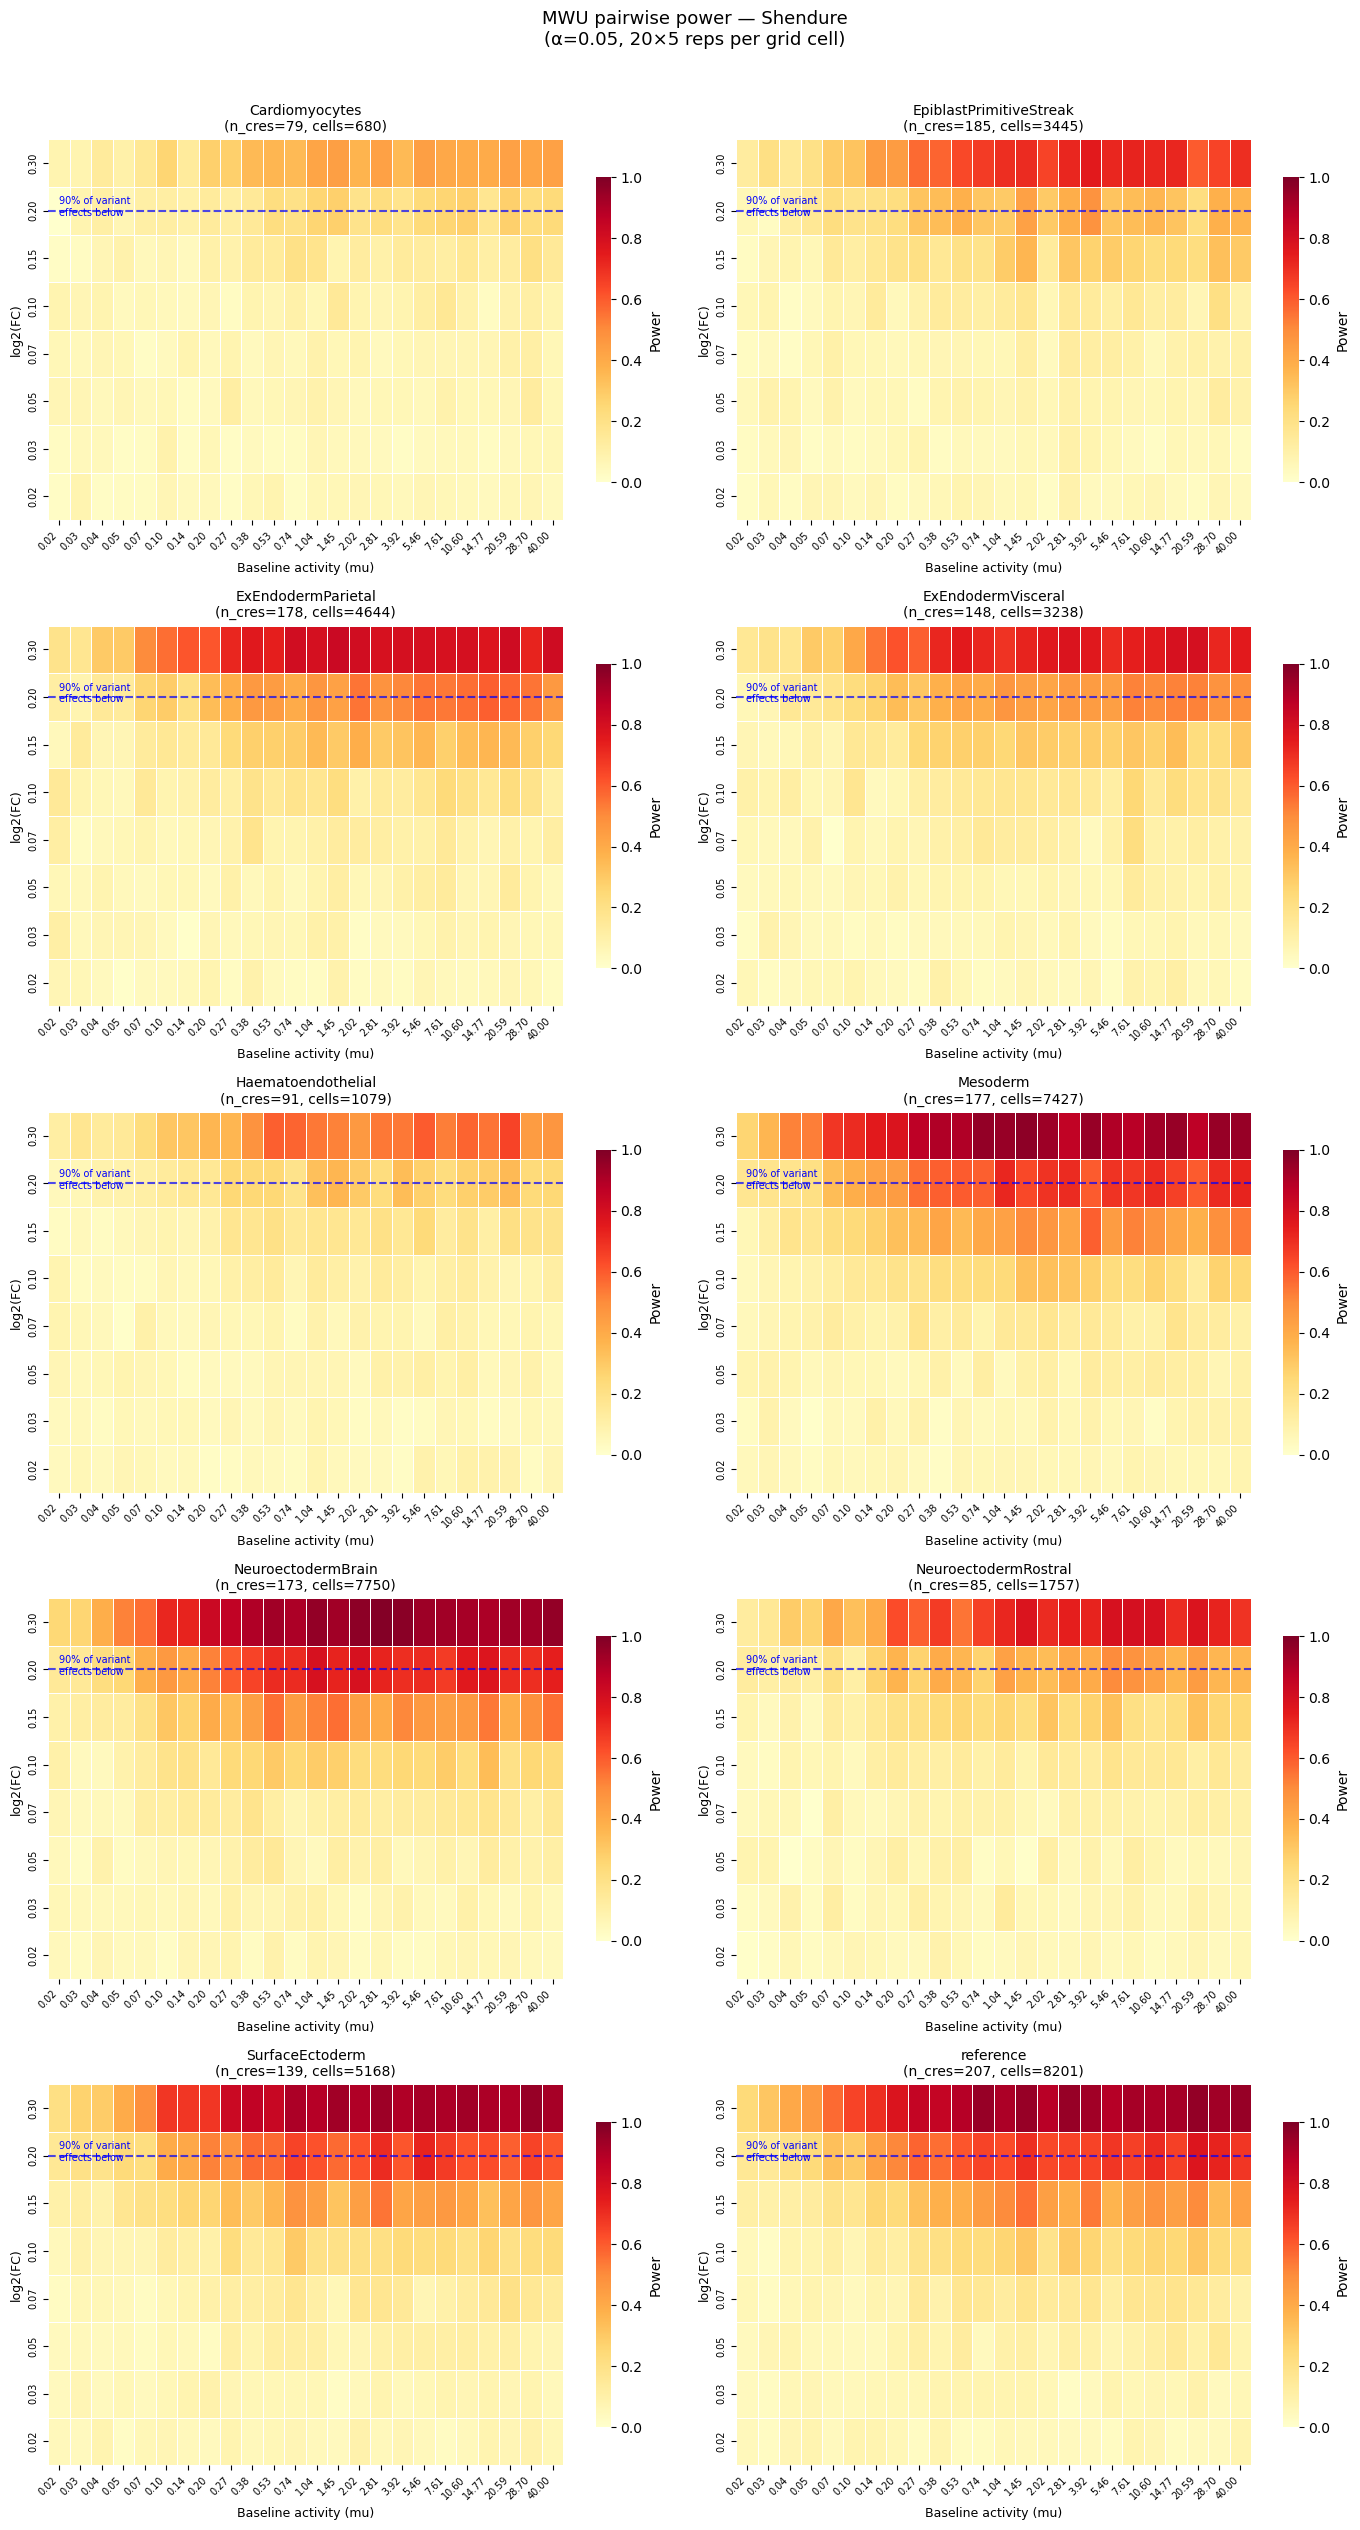

In [12]:
ncols = 2
nrows = int(np.ceil(len(cell_types) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
axes = axes.flatten()

for i, ct in enumerate(cell_types):
    ax = axes[i]
    ct_data = power_grid[power_grid["cell_type"] == ct]
    
    # Pivot to 2D grid
    pivot = ct_data.pivot_table(
        index="log2_fc", columns="baseline_mu", values="power"
    )
    # Sort axes
    pivot = pivot.sort_index(ascending=False)  # high FC on top
    pivot = pivot[sorted(pivot.columns)]  # low baseline on left
    
    cells = scm.SHENDURE_BOUNDS.cells_per_cell_type.get(ct, "?")
    n_cres = n_cres_per_ct[ct]
    
    # Heatmap
    sns.heatmap(
        pivot, ax=ax, vmin=0, vmax=1,
        cmap="YlOrRd", linewidths=0.5, linecolor="white",
        cbar_kws={"label": "Power", "shrink": 0.8},
        xticklabels=[f"{x:.2f}" for x in sorted(pivot.columns)],
        yticklabels=[f"{y:.2f}" for y in pivot.index],
    )
    
    # Mark the 90% variant effect line
    fc_vals = list(pivot.index)
    if 0.20 in fc_vals:
        y_pos = fc_vals.index(0.20) + 0.5
        ax.axhline(y=y_pos, color="blue", linestyle="--", lw=1.5, alpha=0.7)
        ax.text(0.02, y_pos - 0.3, "90% of variant\neffects below",
                transform=ax.get_yaxis_transform(), fontsize=7,
                color="blue", va="top")
    
    ax.set_title(f"{ct}\n(n_cres={n_cres}, cells={cells})", fontsize=10)
    ax.set_xlabel("Baseline activity (mu)", fontsize=9)
    ax.set_ylabel("log2(FC)", fontsize=9)
    ax.tick_params(labelsize=7)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Hide unused axes
for j in range(len(cell_types), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("MWU pairwise power — Shendure\n"
             f"(α=0.05, {n_library_reps}×{n_sims} reps per grid cell)",
             fontsize=13, y=1.01)
plt.tight_layout()

svg_path = output_dir / "pairwise_power_mwu_all_cell_types.svg"
fig.savefig(svg_path, format="svg", bbox_inches="tight")
print(f"Saved: {svg_path}")
plt.show()

## Summary: 80% power contours by cell type

Saved: output/pairwise_power_80pct_contours.svg


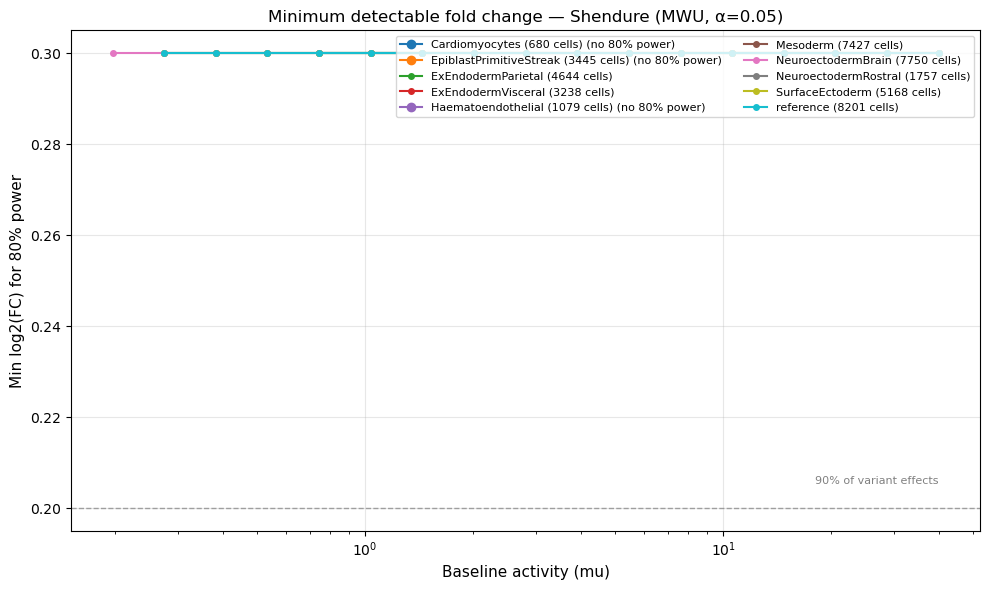

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette("tab10", n_colors=len(cell_types))

for i, ct in enumerate(cell_types):
    ct_data = power_grid[power_grid["cell_type"] == ct]
    
    # For each baseline, find the minimum log2_fc that achieves >= 80% power
    baselines = sorted(ct_data["baseline_mu"].unique())
    min_fc_for_80 = []
    valid_baselines = []
    
    for bl in baselines:
        bl_data = ct_data[ct_data["baseline_mu"] == bl].sort_values("log2_fc")
        above_80 = bl_data[bl_data["power"] >= 0.80]
        if len(above_80) > 0:
            min_fc_for_80.append(above_80["log2_fc"].min())
            valid_baselines.append(bl)
    
    cells = scm.SHENDURE_BOUNDS.cells_per_cell_type.get(ct, "?")
    label = f"{ct} ({cells} cells)"
    
    if valid_baselines:
        ax.plot(valid_baselines, min_fc_for_80, "o-", color=palette[i],
                label=label, markersize=4, lw=1.5)
    else:
        ax.plot([], [], "o-", color=palette[i], label=f"{label} (no 80% power)")

ax.axhline(y=0.20, color="gray", linestyle="--", lw=1, alpha=0.7)
ax.text(ax.get_xlim()[1] * 0.95, 0.205, "90% of variant effects",
        ha="right", va="bottom", fontsize=8, color="gray")

ax.set_xscale("log")
ax.set_xlabel("Baseline activity (mu)", fontsize=11)
ax.set_ylabel("Min log2(FC) for 80% power", fontsize=11)
ax.set_title("Minimum detectable fold change — Shendure (MWU, α=0.05)", fontsize=12)
ax.legend(fontsize=8, loc="upper right", ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()

svg_path2 = output_dir / "pairwise_power_80pct_contours.svg"
fig.savefig(svg_path2, format="svg", bbox_inches="tight")
print(f"Saved: {svg_path2}")
plt.show()

In [14]:
client.close()
cluster.close()

Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
                       ^^^^^^^^^^
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/bokeh/server/session.py", line 88, in _needs_document_lock_wrapper
    with await self._lock.acquire():
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError


Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
                       ^^^^^^^^^^
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/bokeh/server/session.py", line 88, in _needs_document_lock_wrapper
    with await self._lock.acquire():
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError


Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
                       ^^^^^^^^^^
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/bokeh/server/session.py", line 88, in _needs_document_lock_wrapper
    with await self._lock.acquire():
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError


Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
                       ^^^^^^^^^^
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/bokeh/server/session.py", line 88, in _needs_document_lock_wrapper
    with await self._lock.acquire():
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError


Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
                       ^^^^^^^^^^
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/bokeh/server/session.py", line 88, in _needs_document_lock_wrapper
    with await self._lock.acquire():
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError


Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
                       ^^^^^^^^^^
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/bokeh/server/session.py", line 88, in _needs_document_lock_wrapper
    with await self._lock.acquire():
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
asyncio.exceptions.CancelledError


Exception in callback multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540
handle: <Handle multi_future.<locals>.callback(<Task cancell...ession.py:77>>) at /home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py:540>
Traceback (most recent call last):
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/asyncio/events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/tornado/gen.py", line 546, in callback
    result_list.append(f.result())
                       ^^^^^^^^^^
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/bokeh/server/session.py", line 106, in _needs_document_lock_wrapper
    await p
  File "/home/mcn26/.conda/envs/tz/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 284, in send_message
    await message.send(self)
  File "/home/mcn26/.conda/envs/tz/lib/pytho